# Customer Segmentation — Python

Using the `rfm_scores` table built in notebook 02 to label customer segments, 
visualize segment value, and build a cohort retention view.

In [17]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv(dotenv_path='../.env')

username = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
database = os.getenv('DB_NAME')

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

rfm = pd.read_sql("SELECT * FROM rfm_scores", engine)
rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total
0,12636.0,738.0,1,141.00,1,1,1,3
1,17592.0,738.0,1,148.30,1,1,1,3
2,17087.0,737.0,1,221.53,1,1,1,3
3,15833.0,737.0,1,80.40,1,1,1,3
4,13526.0,737.0,2,1182.00,1,2,3,6


## Segment labeling

Mapping `rfm_total` (range 3–12) to human-readable segments. Thresholds are a 
judgment call — adjust based on the actual distribution of your data.

In [18]:
def label_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm['rfm_total'].apply(label_segment)
rfm['segment'].value_counts()

segment
Lost         1719
Champions    1717
At Risk      1244
Loyal        1198
Name: count, dtype: int64

## Segment size vs. revenue contribution

The key chart for this project — does revenue concentration match customer 
count, or is a small segment carrying disproportionate value?

In [19]:
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('monetary', 'sum')
).reset_index()

segment_summary['pct_of_customers'] = (segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100).round(1)
segment_summary['pct_of_revenue'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)

segment_summary.sort_values('total_revenue', ascending=False)

,segment,customer_count,total_revenue,pct_of_customers,pct_of_revenue
1,Champions,1717,1.400587e+07,29.2,80.6
3,Loyal,1198,1.889881e+06,20.4,10.9
0,At Risk,1244,1.000030e+06,21.2,5.8
2,Lost,1719,4.790225e+05,29.2,2.8


C:\Users\mkuya\AppData\Local\Temp\ipykernel_29528\632554395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='segment', y='pct_of_customers', ax=axes[0], palette='viridis')
C:\Users\mkuya\AppData\Local\Temp\ipykernel_29528\632554395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='segment', y='pct_of_revenue', ax=axes[1], palette='viridis')


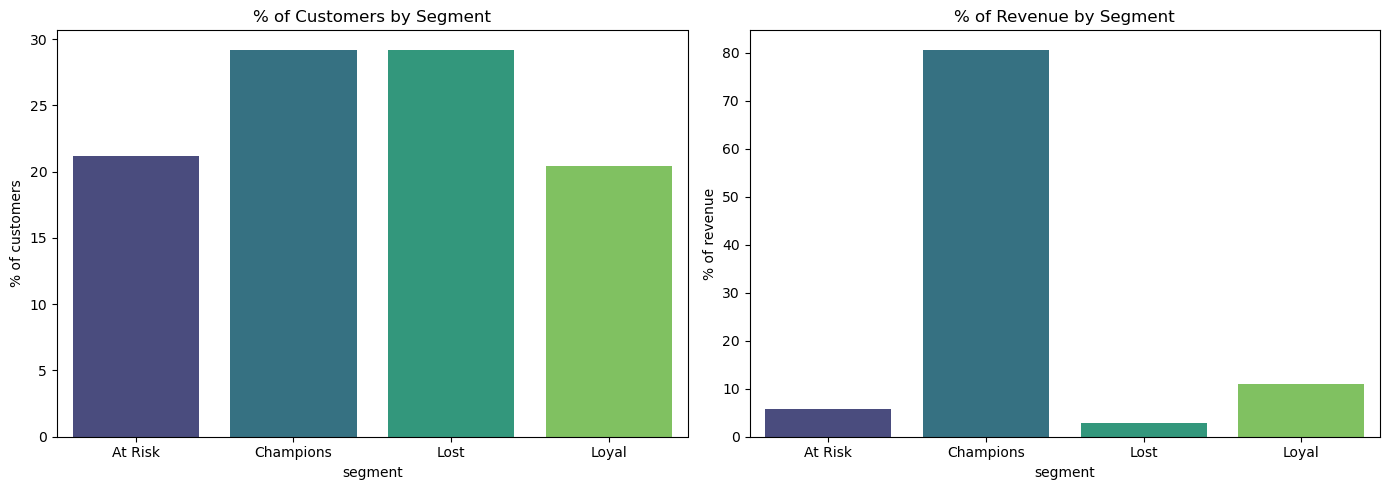

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=segment_summary, x='segment', y='pct_of_customers', ax=axes[0], palette='viridis')
axes[0].set_title('% of Customers by Segment')
axes[0].set_ylabel('% of customers')

sns.barplot(data=segment_summary, x='segment', y='pct_of_revenue', ax=axes[1], palette='viridis')
axes[1].set_title('% of Revenue by Segment')
axes[1].set_ylabel('% of revenue')

plt.tight_layout()
plt.savefig('../outputs/segment_size_vs_revenue.png', dpi=150)
plt.show()

## Cohort retention analysis

For customers grouped by the month of their *first* purchase (their cohort), 
what % are still purchasing in each subsequent month? Requires transaction-level 
data, so this pulls fresh from the `transactions` table rather than `rfm_scores`.

In [21]:
transactions = pd.read_sql("""
    SELECT "Customer ID" AS customer_id, "InvoiceDate" AS invoice_date
    FROM customer
    WHERE is_cancellation = FALSE
""", engine)

transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])
transactions['order_month'] = transactions['invoice_date'].dt.to_period('M')

# First purchase month per customer = their cohort
cohort_map = transactions.groupby('customer_id')['order_month'].min().reset_index()
cohort_map.columns = ['customer_id', 'cohort_month']

transactions = transactions.merge(cohort_map, on='customer_id')
transactions['cohort_index'] = (
    (transactions['order_month'].dt.year - transactions['cohort_month'].dt.year) * 12 +
    (transactions['order_month'].dt.month - transactions['cohort_month'].dt.month)
)

cohort_data = transactions.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)
retention.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN


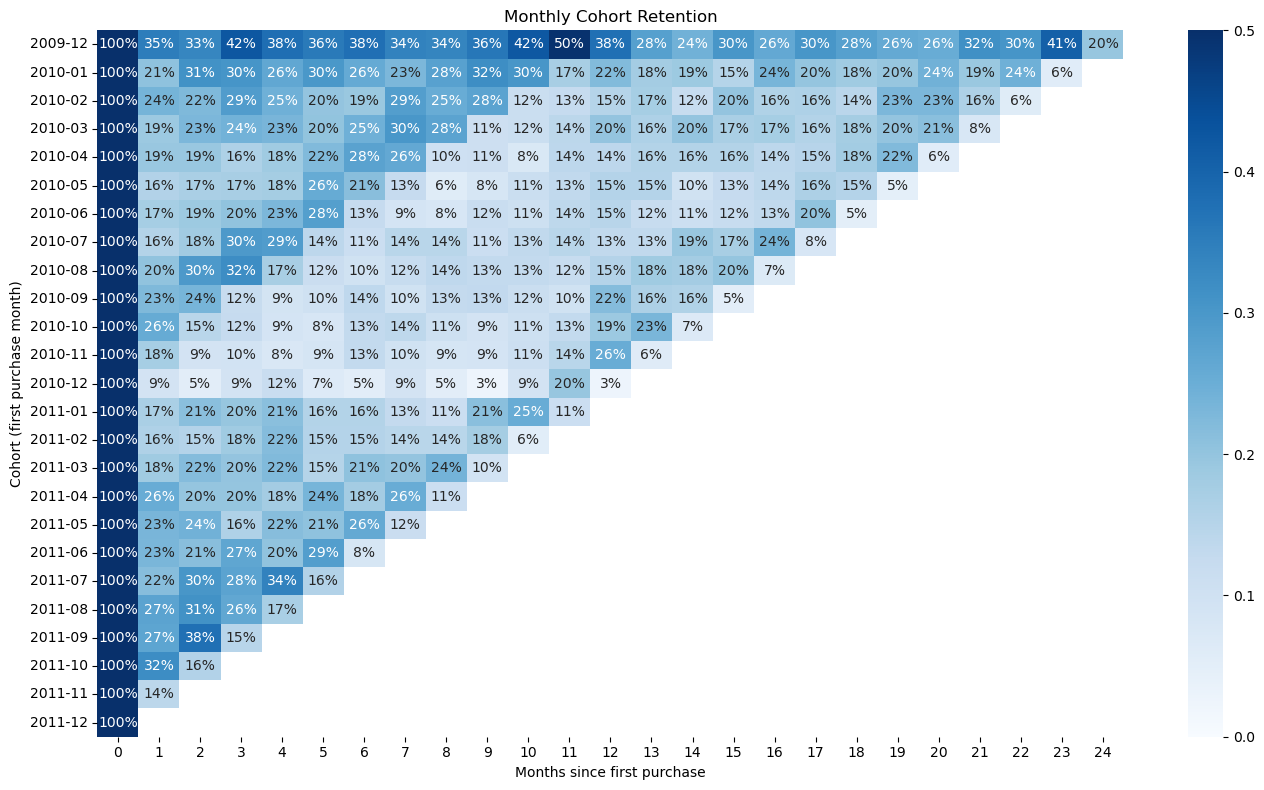

In [22]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=0.5)
plt.title('Monthly Cohort Retention')
plt.ylabel('Cohort (first purchase month)')
plt.xlabel('Months since first purchase')
plt.tight_layout()
plt.savefig('../outputs/cohort_retention_heatmap.png', dpi=150)
plt.show()

## Export for dashboard

Saving a summary CSV that Tableau/Power BI will connect to directly, rather 
than connecting the BI tool straight to Postgres — keeps the dashboard 
reproducible even if the DB isn't running.

In [23]:
rfm.to_csv('../outputs/rfm_customer_segments.csv', index=False)
segment_summary.to_csv('../outputs/segment_summary.csv', index=False)
print("Exports saved to /outputs")

Exports saved to /outputs


## Findings summary

- **Revenue concentration is extreme.** Champions make up only 29.2% of customers 
  but generate 80.6% of total revenue. Lost customers make up the same at 29.2% 
  but contribute just 2.8% of revenue. A relatively small, high-value group is 
  carrying the business, which makes retention of that specific segment a 
  higher priority than broad reactivation of the Lost segment.

- **At Risk (21.2% of customers, 5.8% of revenue) is worth watching closely**  
  These customers haven't fully disengaged like "Lost," but 
  aren't Loyal/Champion-level either. A targeted win-back campaign here has a 
  shorter path to revenue recovery than trying to reactivate Lost customers.

- **Cohort retention doesn't show a sharp one-time drop-off** it declines from 
  100% (month 0, by definition) to roughly 20-35% by month 1 and then stays 
  fairly stable in that 15-30% range for most cohorts through month 20+, rather 
  than decaying to near zero. This suggests customers who return at all tend to 
  stick around, so the bigger opportunity is converting more first-time buyers 
  into any repeat purchase, not just fighting long-term churn.

- **Earlier cohorts (Dec 2009) retained better than cohorts starting a few months 
  later** (Jan-Apr 2010 cohorts run roughly 5-15 points lower in month-1 retention) 
  — worth noting, though the shorter observation window for later cohorts makes 
  this a weaker signal than the segment/revenue finding above.

- **Recommendation:** prioritize a Champions retention program (e.g., early access, 
  loyalty perks) given their outsized revenue share, and a targeted At Risk win-back 
  campaign (e.g., a discount or re-engagement email) rather than broad Lost-segment 
  outreach, since